<a href="https://colab.research.google.com/github/JulioDeca/Workshop26.1---16.03.2026-20.03.2026/blob/main/Desafio_final_python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving banco_box_sintetico.csv to banco_box_sintetico (2).csv
   idade  renda_mensal  tempo_emprego  dividas_total  limite_cartao  \
0     50       4145.83            1.4           5798       13957.29   
1     40      14080.13            0.9          39607       57549.72   
2     59       7550.31           21.0           7865       20694.49   
3     27       2390.01            5.6           1340       10593.18   
4     39      17135.27           20.3          45245       77949.94   

   historico_credito  num_cartoes_credito  num_emprestimos  atraso_pagamento  \
0                  1                    1                1                 0   
1                  1                    0                2                 0   
2                  3                    4                0                 0   
3                 17                    5                3                 0   
4                  1                    3                2                 0   

  possui_imovel possui_veiculo

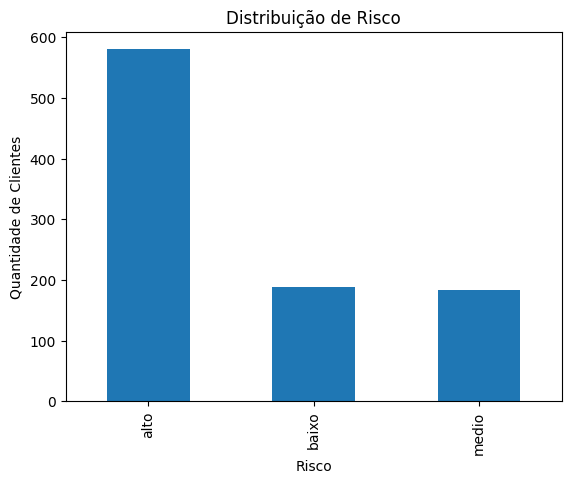


Relatório de Classificação:
              precision    recall  f1-score   support

        alto       0.70      0.70      0.70       178
       baixo       0.29      0.30      0.29        57
       medio       0.26      0.25      0.26        51

    accuracy                           0.54       286
   macro avg       0.42      0.42      0.42       286
weighted avg       0.54      0.54      0.54       286



In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

uploaded = files.upload()

try:
    df = pd.read_csv('banco_box_sintetico.csv', encoding='utf-16')
except:
    df = pd.read_csv('banco_box_sintetico.csv', encoding='utf-8')

print(df.head())

df['renda_mensal'] = pd.to_numeric(df['renda_mensal'], errors='coerce')
df['dividas_total'] = pd.to_numeric(df['dividas_total'], errors='coerce')
df['tempo_emprego'] = pd.to_numeric(df['tempo_emprego'], errors='coerce')

df = df.dropna()

media = np.mean(df['dividas_total'])
print("\nMédia das dívidas:", media)

def classificar_risco(divida):
    if divida > 10000:
        return 'alto'
    elif divida > 5000:
        return 'medio'
    else:
        return 'baixo'
df['risco'] = df['dividas_total'].apply(classificar_risco)

df['risco'].value_counts().plot(kind='bar')
plt.title("Distribuição de Risco")
plt.xlabel("Risco")
plt.ylabel("Quantidade de Clientes")
plt.show()

X = df[['idade', 'renda_mensal', 'tempo_emprego']]
y = df['risco']

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.3, random_state=42
)

modelo = DecisionTreeClassifier()
modelo.fit(X_treino, y_treino)

y_pred = modelo.predict(X_teste)

print("\nRelatório de Classificação:")
print(classification_report(y_teste, y_pred))

df.to_csv("dados_tratados.csv", index=False)

Saving dados_concessionaria.csv to dados_concessionaria (5).csv
       km   ano  combustivel  marca  cambio  preco_alto
0  152315  2022            2      2       1           1
1  151439  2024            0      1       1           1
2  145623  2011            2      2       1           0
3  156695  2014            0      1       1           0
4   20359  2017            2      0       0           0
Acuracia: 0.3333333333333333
Matriz de Confusao:
 [[0 0 0]
 [1 0 2]
 [1 0 2]]

Resultados do modelo:
MAE: 0.8333333333333334
MSE: 1.1666666666666667
R2: -3.666666666666667


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


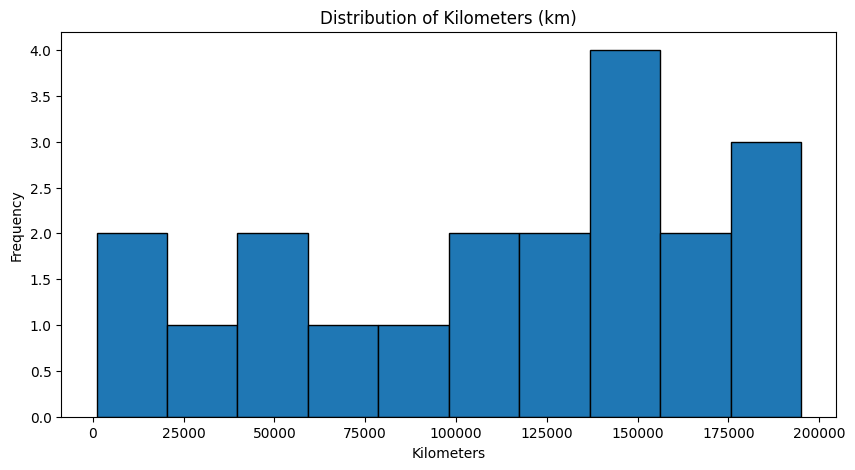

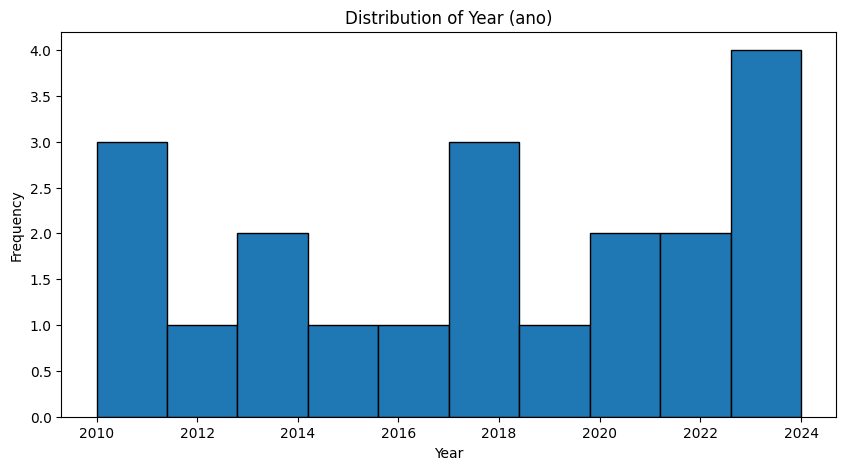

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, mean_absolute_error, mean_squared_error, r2_score

uploaded = files.upload()

try:
    df = pd.read_csv('dados_concessionaria.csv', encoding='utf-16')
except:
    df = pd.read_csv('dados_concessionaria.csv', encoding='utf-8')

print(df.head())

x = df[['km','ano', 'preco_alto']]
y = df['marca']

X_treino, X_teste, y_treino, y_teste = train_test_split(x, y, test_size=0.3, random_state=42)

modelo = LogisticRegression()

modelo.fit(X_treino, y_treino)

y_pred = modelo.predict(X_teste)

mae = mean_absolute_error(y_teste, y_pred)
mse = mean_squared_error(y_teste, y_pred)
r2 = r2_score(y_teste, y_pred)
acuracia = accuracy_score(y_teste, y_pred)
matriz = confusion_matrix(y_teste, y_pred)

print("Acuracia:", acuracia)
print("Matriz de Confusao:\n", matriz)
print("\nResultados do modelo:")
print("MAE:",mae)
print("MSE:",mse)
print("R2:",r2)

plt.figure(figsize=(10, 5))
plt.hist(df['km'], bins=10, edgecolor='black')
plt.title('Distribution of Kilometers (km)')
plt.xlabel('Kilometers')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(10, 5))
plt.hist(df['ano'], bins=10, edgecolor='black')
plt.title('Distribution of Year (ano)')
plt.xlabel('Year')
plt.ylabel('Frequency')
plt.show()

# Task
Fix the `IndentationError` in the first code cell by indenting the `df = pd.read_csv(...)` lines under their respective `try` and `except` blocks, then execute the cell and verify that the `df` DataFrame is loaded correctly and `df.head()` displays the expected output.

## Fix Indentation

### Subtask:
Indent the lines `df = pd.read_csv(...)` under the `try` block and `df = pd.read_csv(...)` under the `except` block to resolve the `IndentationError`.
